In [102]:
from ztpcraft.projects.fluxonium.multiloop_fluxonium.two_loop_fluxonium_with_arrays_normal_modes import TwoLoopArrayFluxonium
from ztpcraft.bosonic.oscillator_integrals.oscillator_overlap import OscillatorOverlapEngine
from ztpcraft.bosonic.oscillator_integrals.oscillators import LocalHarmonicOscillator
import ztpcraft as ztpc
import numpy as np
import matplotlib.pyplot as plt

In [97]:
param_set = {}
param_set["qC_standalone_symmetric"] = {
    "EJa": 58.5,
    "CJa": ztpc.tb.units.EC_2_capacitance(0.685),  # fF
    "Cga": 0.25,  # fF
    "EJb": 6.16,
    "CJb": ztpc.tb.units.EC_2_capacitance(0.825),  # fF
    "N": 117,
}

model = TwoLoopArrayFluxonium(param_set["qC_standalone_symmetric"])

oscillator_system = model.build_system(
    phi_ext_A=np.pi, phi_ext_B=-np.pi, sectors=[(-1,0),(0, 0), (0, 1), (0, -1)]
)

In [98]:
fock_state_1 = [0]*233
fock_state_2 = [0]*233
fock_state_1[0] = 0
fock_state_2[0] = 0
oscillator_system.overlap(
    "Pa_0_Pb_0_minidx_0",
    "Pa_0_Pb_1_minidx_0",
    tuple(fock_state_1),
    tuple(fock_state_2),
)

1.8413048617283294e-21

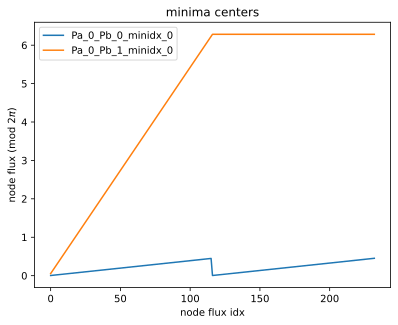

In [106]:
fig, ax = plt.subplots()
ax.plot(model.minima_data["Pa_0_Pb_0_minidx_0"].oscillator.center, label="Pa_0_Pb_0_minidx_0")
ax.plot(model.minima_data["Pa_0_Pb_1_minidx_0"].oscillator.center, label="Pa_0_Pb_1_minidx_0")
ax.legend()
ax.set_xlabel("node flux idx")
ax.set_ylabel("node flux (mod $2\pi$)")
ax.set_title("minima centers")
plt.show()

In [114]:
osc_00 = model.minima_data["Pa_0_Pb_0_minidx_0"].oscillator
osc_01 = model.minima_data["Pa_0_Pb_1_minidx_0"].oscillator
shift_by_2pi = -np.ones(osc_01.dim)
shift_by_2pi[:75] = 0
osc_01_shifted_center = LocalHarmonicOscillator(
    osc_01.transform_xi_theta,
    osc_01.transform_qn,
    osc_01.frequencies,
    osc_01.center + 2*np.pi*shift_by_2pi,
)

ovlp_engine = OscillatorOverlapEngine(
    osc_01_shifted_center,
    osc_00,
)
ovlp_engine.overlap(
    tuple(fock_state_1),
    tuple(fock_state_2),
)


3.886602339472449e-15

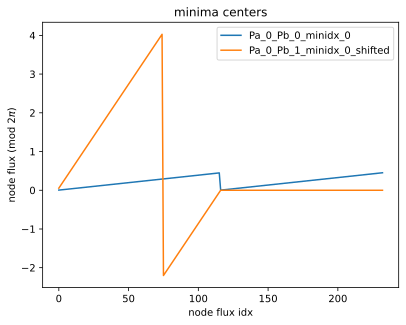

In [115]:
fig, ax = plt.subplots()
ax.plot(osc_00.center, label="Pa_0_Pb_0_minidx_0")
ax.plot(osc_01_shifted_center.center, label="Pa_0_Pb_1_minidx_0_shifted")
ax.legend()
ax.set_xlabel("node flux idx")
ax.set_ylabel("node flux (mod $2\pi$)")
ax.set_title("minima centers")
plt.show()